# Proyecto Parte 1

### Importación de Librerías

In [ ]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns

### Inspección del Dataset

In [ ]:
df = pd.read_csv('Aguas_superficiales_2020.csv', encoding='latin-1')
df.sample(6)

,CLAVE,SITIO,ORGANISMO_DE_CUENCA,ESTADO,MUNICIPIO,CUENCA,CUERPO DE AGUA,TIPO,SUBTIPO,LONGITUD,...,CONTAMINANTES,CUMPLE_CON_DBO,CUMPLE_CON_DQO,CUMPLE_CON_SST,CUMPLE_CON_CF,CUMPLE_CON_E_COLI,CUMPLE_CON_ENTEROC,CUMPLE_CON_OD,CUMPLE_CON_TOX,GRUPO
1461,DLTAB2420M1,RIO SAMARIA 5,FRONTERA SUR,TABASCO,CUNDUACAN,SamarIa,RIO SAMARIA,LOTICO,RIO,-93.04,...,"CF,",SI,SI,SI,NO,SI,ND,SI,SI,LOTICO
499,DLGUA1157,RIO LERMA 15,LERMA SANTIAGO PACIFICO,GUANAJUATO,ACAMBARO,RIO LERMA 4,RIO LERMA,LOTICO,RIO,-100.68,...,"DQO,OD%L,",SI,NO,SI,SI,SI,ND,NO,SI,LOTICO
2878,OCPBC4279,TIJUANA I,PENINSULA DE BAJA CALIFORNIA,BAJA CALIFORNIA,TIJUANA,TIJUANA,OCEANO PACIFICO,COSTERO,OCEANO-MAR,-117.12,...,NaN,ND,ND,SI,ND,ND,SI,SI,SI,COSTERO
2277,OCGCE3453,PUENTE COATZACOALCOS II,GOLFO CENTRO,VERACRUZ DE IGNACIO DE LA LLAVE,IXHUATLAN DEL SURESTE,BAJO RIO UXPANAPA,RIO COATZACOALCOS,LOTICO (HUMEDAL),RIO,-94.45,...,"CF,",SI,SI,SI,NO,SI,ND,SI,SI,LOTICO
2030,OCGCE3182,TESECHOACAN,GOLFO CENTRO,VERACRUZ DE IGNACIO DE LA LLAVE,ISLA,RIO TESECHOACAN,RIO TESECHOACAN,LOTICO (HUMEDAL),RIO,-95.65,...,"SST,CF,E_COLI,",SI,SI,NO,NO,NO,ND,SI,SI,LOTICO
3096,OCPNO4633,LAGUNA HUIZACHE 2,PACIFICO NORTE,SINALOA,ROSARIO,GRUPO DE CORRIENTES HUIZACHE,LAGUNA HUIZACHE,COSTERO (HUMEDAL),LAGUNA,-106.05,...,NaN,ND,ND,SI,ND,ND,SI,SI,SI,COSTERO


### **Descripción de las variables**

**Datos Generales del Sitio**

* CLAVE: Clave del sitio de monitoreo.

* SITIO: Nombre del sitio de muestreo.

* ORGANISMO_DE_CUENCA: Nombre del Organismo de Cuenca de agua donde se localiza el sitio de monitoreo

* ESTADO: Estado de la República Mexicana en el que se localiza el sitio de monitoreo.

* MUNICIPIO: Municipio correspondiente al sitio de muestreo.

* CUENCA: Nombre de la cuenca donde se localiza el sitio de monitoreo.

* CUERPO_DE_AGUA: Nombre del cuerpo de agua donde se localiza el sitio de monitoreo.

* TIPO: Tipo de cuerpo de agua donde se encuentra el sitio de muestreo

* SUBTIPO: Subtipo de cuerpo de agua donde se encuentra el sitio de muestreo.

* LONGITUD: Coordenada geográfica de longitud del sitio de muestreo.

* LATITUD: Coordenada geográfica de latitud del sitio de muestreo.

* PERIODO: Año en el que se realizó la muestra (en este caso 2020).

**Parámetros Fisicoquímicos y Microbiológicos**

* DBO_mg/L: Demanda Bioquímica de Oxígeno (mg/L).

* CALIDAD_DBO: Clasificación cualitativa de la calidad del agua según los niveles de DBO.

* DQO_mg/L: Demanda Química de Oxígeno (mg/L).

* CALIDAD_DQO: Clasificación de la calidad del agua basada en los valores de DQO.

* SST_mg/L: Sólidos Suspendidos Totales (mg/L). Indica la cantidad de partículas suspendidas en el agua.

* CALIDAD_SST: Clasificación cualitativa de la calidad del agua según SST.

* COLI_FEC_NMP_100mL: Número Más Probable de coliformes fecales por 100 mL. Indica contaminación fecal.

* CALIDAD_COLI_FEC: Clasificación de la calidad del agua según el nivel de coliformes fecales.

* E_COLI_NMP_100mL: Número Más Probable de E. coli por 100 mL. Indicador específico de contaminación fecal reciente.

* CALIDAD_E_COLI: Clasificación cualitativa del agua basada en E. coli.

* ENTEROC_NMP_100mL: Número Más Probable de enterococos por 100 mL.

* CALIDAD_ENTEROC: Clasificación de la calidad del agua según el nivel de enterococos.


  **Oxígeno Disuelto (OD)**
* OD_PORC: Valor de Porcentaje de saturacion de oxigeno disuelto, en cuerpos loticos.

* CALIDAD_OD_PORC: Clasificación de calidad basada en OD_PORC.

* OD_PORC_SUP: Valor de Porcentaje de saturacion de oxigeno disuelto superficial.

* CALIDAD_OD_PORC_SUP: Clasificación de calidad para OD en superficie.

* OD_PORC_MED: Valor de Porcentaje de saturacion de oxigeno disuelto medio.

* CALIDAD_OD_PORC_MED: Clasificación cualitativa según OD en media profundidad.

* OD_PORC_FON: Valor de Porcentaje de saturacion de oxigeno disuelto en fondo.

* CALIDAD_OD_PORC_FON: Clasificación de OD en fondo (sin datos).

**Toxicidad (Bioensayos)**

* TOX_D_48_UT: Toxicidad directa a 48 horas (Unidades Tóxicas).

* CALIDAD_TOX_D_48: Clasificación según la toxicidad directa a 48 horas.

* TOX_V_15_UT: Toxicidad por volatilización a 15 minutos (UT).

* CALIDAD_TOX_V_15: Clasificación cualitativa para toxicidad volatilizada.

* TOX_D_48_SUP_UT: Toxicidad a 48 horas (superficie).

* CALIDAD TOX_D_48_SUP: Clasificación para TOX_D_48_SUP.

* TOX_D_48_FON_UT: Toxicidad a 48 horas (fondo) – sin datos.

* CALIDAD_TOX_D_48_FON: Clasificación para toxicidad en el fondo – sin datos.

* TOX_FIS_SUP_15_UT: Toxicidad física (superficie) a 15 minutos (UT).

* CALIDAD_TOX_FIS_SUP_15: Clasificación cualitativa para TOX_FIS_SUP_15.

* TOX_FIS_FON_15_UT: Toxicidad física (fondo) a 15 minutos – sin datos.

* CALIDAD_TOX_FIS_FON_15: Clasificación para TOX_FIS_FON_15 – sin datos.

**Evaluación General y Cumplimiento**

* SEMAFORO: Indica el nivel de contaminacion de acuerdo a los contaminantes presentes.

* CONTAMINANTES: Lista de contaminantes detectados en el sitio.

* CUMPLE_CON_DBO: Indicador de cumplimiento con el valor guía para DBO.

* CUMPLE_CON_DQO: Indicador de cumplimiento con el valor guía para DQO.

* CUMPLE_CON_SST: Indicador de cumplimiento con el valor guía para SST.

* CUMPLE_CON_CF: Indicador de cumplimiento con el valor guía para coliformes fecales.

* CUMPLE_CON_E_COLI: Indicador de cumplimiento con el valor guía para E. coli.

* CUMPLE_CON_ENTEROC: Indicador de cumplimiento con el valor guía para enterococos.

* CUMPLE_CON_OD: Indicador de cumplimiento con el valor guía para oxígeno disuelto.

* CUMPLE_CON_TOX: Indicador de cumplimiento con el valor guía para toxicidad.

**Clasificación Adicional**

* GRUPO: Grupo del cuerpo de agua.



In [ ]:
# Revisar la forma del Dataset
print("Número de filas: ",df.shape[0])
print("Número de columnas: ",df.shape[1])

Número de filas:  4141
Número de columnas:  55


In [ ]:
df.info() #Muestra un resumen del Dataset

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4141 entries, 0 to 4140
Data columns (total 55 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   CLAVE                   3493 non-null   object 
 1   SITIO                   3493 non-null   object 
 2   ORGANISMO_DE_CUENCA     3493 non-null   object 
 3   ESTADO                  3493 non-null   object 
 4   MUNICIPIO               3493 non-null   object 
 5   CUENCA                  3492 non-null   object 
 6   CUERPO DE AGUA          3479 non-null   object 
 7   TIPO                    3493 non-null   object 
 8   SUBTIPO                 3479 non-null   object 
 9   LONGITUD                3493 non-null   float64
 10  LATITUD                 3493 non-null   float64
 11  PERIODO                 3493 non-null   float64
 12  DBO_mg/L                2581 non-null   object 
 13  CALIDAD_DBO             2581 non-null   object 
 14  DQO_mg/L                2581 non-null   

**Observaciones**

*   Inconsistencias en los nombres de las columnas.
*   Columnas sin datos.
*   Tipos de datos incorrectos.




## 1. Limpieza de Datos

In [ ]:
# Limpiar nombres de columnas
df.columns = (
    df.columns
    .str.strip()  # Elimina espacios al inicio y al final
    .str.replace(r'\s+', ' ', regex=True)  # Reemplaza múltiples espacios por uno
    .str.replace(' ', '_')  # Reemplaza espacios por guiones bajos
)

pd.DataFrame(df.columns, columns=['Nombre de la Columna'])

,Nombre de la Columna
0,CLAVE
1,SITIO
2,ORGANISMO_DE_CUENCA
3,ESTADO
4,MUNICIPIO
5,CUENCA
6,CUERPO_DE_AGUA
7,TIPO
8,SUBTIPO
9,LONGITUD


### Revisión de Filas Vacías

In [ ]:
#Identificar filas vacías
print("Cantidad de filas vacías: ", df.isnull().all(axis=1).sum())

Cantidad de filas vacías:  648


Existen 648 filas vacías, por lo que proceemos a eliminarlas

In [ ]:
df = df.dropna(how='all')
df.shape

(3493, 55)

### Revisión de Duplicados

In [ ]:
# Verificar valores duplicadas
duplicados = df[df.duplicated()]
duplicados

,CLAVE,SITIO,ORGANISMO_DE_CUENCA,ESTADO,MUNICIPIO,CUENCA,CUERPO_DE_AGUA,TIPO,SUBTIPO,LONGITUD,...,CONTAMINANTES,CUMPLE_CON_DBO,CUMPLE_CON_DQO,CUMPLE_CON_SST,CUMPLE_CON_CF,CUMPLE_CON_E_COLI,CUMPLE_CON_ENTEROC,CUMPLE_CON_OD,CUMPLE_CON_TOX,GRUPO


No existen filas duplicadas en el Dataset.

### Revisión de Valores Nulos

In [ ]:
#Revisión de valores nulos
nulos = df.isnull().sum()
porcentaje_nulos = (nulos / len(df) * 100).round(0)

resumen_nulos = pd.DataFrame({
    'Nulos': nulos,
    'Porcentaje (%)': porcentaje_nulos
})

resumen_nulos = resumen_nulos.sort_values(by='Nulos', ascending=False)# Ordenar por cantidad de nulos
resumen_nulos

,Nulos,Porcentaje (%)
TOX_FIS_FON_15_UT,3493,100.00
CALIDAD_TOX_FIS_FON_15,3493,100.00
TOX_D_48_FON_UT,3493,100.00
CALIDAD_TOX_D_48_FON,3493,100.00
OD_PORC_MED,3006,86.00
CALIDAD_OD_PORC_MED,3006,86.00
CALIDAD_TOX_D_48_SUP,2731,78.00
TOX_D_48_SUP_UT,2731,78.00
ENTEROC_NMP_100mL,2589,74.00
CALIDAD_ENTEROC,2589,74.00


En este caso se consideran aceptables aquellas variables que presenten menos del 60% de valores nulos. Por lo tanto, se eliminan las 12 columnas que no cumplen con este criterio, ya que no aportan suficiente información para los análisis.

In [ ]:
# Eliminar columnas con más de 60% de nulos
columnas_eliminar = resumen_nulos[resumen_nulos['Porcentaje (%)'] > 60].index
df = df.drop(columns=columnas_eliminar)
print(f"Columnas eliminadas: {columnas_eliminar.tolist()}")
df.shape

# Eliminar valor nulo de la columna CUENCA
df = df[df['CUENCA'].notna()]

Columnas eliminadas: ['TOX_FIS_FON_15_UT', 'CALIDAD_TOX_FIS_FON_15', 'TOX_D_48_FON_UT', 'CALIDAD_TOX_D_48_FON', 'OD_PORC_MED', 'CALIDAD_OD_PORC_MED', 'CALIDAD_TOX_D_48_SUP', 'TOX_D_48_SUP_UT', 'ENTEROC_NMP_100mL', 'CALIDAD_ENTEROC', 'CALIDAD_OD_PORC_FON', 'OD_PORC_FON']


In [ ]:
#Revisión de valores nulos para confirmar eliminación de columnas
nulos = df.isnull().sum()
porcentaje_nulos = (nulos / len(df) * 100).round(0)

resumen_nulos = pd.DataFrame({
    'Nulos': nulos,
    'Porcentaje (%)': porcentaje_nulos
})

resumen_nulos = resumen_nulos.sort_values(by='Nulos', ascending=False)# Ordenar por cantidad de nulos
resumen_nulos

,Nulos,Porcentaje (%)
OD_PORC_SUP,1874,54.00
CALIDAD_OD_PORC_SUP,1874,54.00
CALIDAD_TOX_FIS_SUP_15,1819,52.00
TOX_FIS_SUP_15_UT,1819,52.00
CALIDAD_OD_PORC,1695,49.00
OD_PORC,1695,49.00
TOX_D_48_UT,1676,48.00
CALIDAD_TOX_D_48,1676,48.00
TOX_V_15_UT,1673,48.00
CALIDAD_TOX_V_15,1673,48.00


### Revisión de Valores Únicos en las Columnas

In [ ]:
# Eliminar espacios en blanco en los datos
df = df.apply(lambda x: x.str.strip() if x.dtype == "object" else x)

In [ ]:
for col in df.columns:
    print(f"Columna: {col}")
    print(df[col].unique())
    print("---------------")

Columna: CLAVE
['DLAGU8' 'DLBAJ100' 'DLBAJ101' ... 'OCRBR5208M1' 'OCRBR5209M1'
 'OCRBR5210M1']
---------------
Columna: SITIO
['PRESA EL SAUCILLO 100M AGUAS ARRIBA DE LA CORTINA'
 'LOS CABOS SEG 22, 2 ISA10B' 'LOS CABOS SEG 22, 1 ISA10B' ...
 'PUENTE INTERNACIONAL I NUEVO LAREDO' 'RIO BRAVO FRENTE A COMAPA'
 'RIO BRAVO 8 (PASO DE LOS INDIOS)']
---------------
Columna: ORGANISMO_DE_CUENCA
['LERMA SANTIAGO PACIFICO' 'PENINSULA DE BAJA CALIFORNIA'
 'PENINSULA DE YUCATAN' 'RIO BRAVO' 'NOROESTE'
 'CUENCAS CENTRALES DEL NORTE' 'PACIFICO NORTE' 'BALSAS'
 'AGUAS DEL VALLE DE MEXICO' 'GOLFO NORTE' 'PACIFICO SUR' 'GOLFO CENTRO'
 'FRONTERA SUR']
---------------
Columna: ESTADO
['AGUASCALIENTES' 'BAJA CALIFORNIA SUR' 'CAMPECHE' 'CHIHUAHUA'
 'COAHUILA DE ZARAGOZA' 'COLIMA' 'MICHOACAN DE OCAMPO' 'DURANGO' 'MEXICO'
 'MORELOS' 'QUERETARO ARTEAGA' 'GUANAJUATO' 'GUERRERO' 'HIDALGO' 'JALISCO'
 'NAYARIT' 'PUEBLA' 'VERACRUZ DE IGNACIO DE LA LLAVE' 'QUINTANA ROO'
 'SAN LUIS POTOSI' 'TABASCO' 'CHIAPAS' 'TLAX

A partir de la revisión de los valores únicos de cada columna se identifican varios errores:

*   Valores de tipo texto (Ej: <1) en columnas que deben ser de tipo numérico
*   Columnas de texto con letras y mayúsculas y minúsculas (Ej: "PrEsa").
*   Textos escritos erróneamente (EJ: LAGUNA DEL POM Y ATASTA en lugar de: LAGUNA DE POM Y ATASTA)
*   Celdas con el texto "ND" en lugar de NaN.


### Sustitución de valores

In [ ]:
# Reemplazo de celdas en blanco o "ND" por NaN y reemplazar texto no numérico por numérico
df.replace({
    "<1": 0.9,
    "<2": 1.9,
    "<3": 2.9,
    "<10": 9.9,
    "ND": np.nan,
    "": np.nan
}, inplace=True)

# Convertir columnas de texto a mayúsculas para eliminar inconsistencias
columnas_a_mayusculas = ['CLAVE','SITIO','ORGANISMO_DE_CUENCA','ESTADO','MUNICIPIO','CUENCA','CUERPO_DE_AGUA','SUBTIPO']
for col in columnas_a_mayusculas:
    df[col] = df[col].str.upper()

# Eliminar espacios dobles en los textos
for col in df:
    df[col] = df[col].apply(lambda x: ' '.join(x.split()) if isinstance(x, str) else x)

# Reemplazar texto escrito erróneamente
df['CUENCA'] = df['CUENCA'].replace('LAGUNA DEL POM Y ATASTA', 'LAGUNA DE POM Y ATASTA')

#Elminar celdas sin datos de contaminantes
df = df.dropna(subset=['CALIDAD_SST'])

### Identificación de Duplicados

In [ ]:
# Verificar si hay filas duplicadas
duplicados = df.duplicated().sum()
print(f"Hay {duplicados} filas duplicadas.")

Hay 0 filas duplicadas.


### Definición de Tipo de Datos

In [ ]:
#Revisión de los tipos de datos de las columnas
df.dtypes

,0
CLAVE,object
SITIO,object
ORGANISMO_DE_CUENCA,object
ESTADO,object
MUNICIPIO,object
CUENCA,object
CUERPO_DE_AGUA,object
TIPO,object
SUBTIPO,object
LONGITUD,float64


Se identifica que los tipos de datos de las variables están mal asignados, por lo que procedemos a asignarlos manualmente.

In [ ]:
#Especificar las columnas numéricas (float)
columnas_a_convertir = [col for col in df.columns if col.startswith(('TOX', 'OD', 'SST', 'DQO', 'DBO', 'LONGITUD', 'LATITUD'))]
# Especificar las columnas numéricas (integer)
columnas_a_convertir_int = ['COLI_FEC_NMP_100mL', 'E_COLI_NMP_100mL', 'PERIODO']

#Convertir las columnas a tipo float
df[columnas_a_convertir] = df[columnas_a_convertir].apply(pd.to_numeric, errors='coerce')
# Convertir esas columnas a tipo entero
df[columnas_a_convertir_int] = df[columnas_a_convertir_int].apply(pd.to_numeric, errors='coerce').fillna(0).astype(int)

<ipython-input-589-4d3e67eac7e8>:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[columnas_a_convertir] = df[columnas_a_convertir].apply(pd.to_numeric, errors='coerce')
<ipython-input-589-4d3e67eac7e8>:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[columnas_a_convertir_int] = df[columnas_a_convertir_int].apply(pd.to_numeric, errors='coerce').fillna(0).astype(int)


In [ ]:
df.dtypes

,0
CLAVE,object
SITIO,object
ORGANISMO_DE_CUENCA,object
ESTADO,object
MUNICIPIO,object
CUENCA,object
CUERPO_DE_AGUA,object
TIPO,object
SUBTIPO,object
LONGITUD,float64


# 2. Exploración de Base de Datos

In [ ]:
#Resumen básico de las estadísticas descriptivas
df.describe().T

,count,mean,std,min,25%,50%,75%,max
LONGITUD,"3,488.00",-100.36,6.12,-117.12,-103.86,-99.79,-96.86,-86.73
LATITUD,"3,488.00",21.05,3.89,14.53,18.40,20.15,22.83,32.71
PERIODO,"3,488.00","2,020.00",0.00,"2,020.00","2,020.00","2,020.00","2,020.00","2,020.00"
DBO_mg/L,"2,578.00",16.81,65.17,1.90,1.90,2.63,10.00,"1,500.00"
DQO_mg/L,"2,578.00",64.15,149.79,9.90,11.87,26.98,56.93,"2,871.25"
SST_mg/L,"3,488.00",102.15,441.93,9.90,9.90,24.31,57.04,"9,430.00"
COLI_FEC_NMP_100mL,"3,488.00","70,798.94","1,006,511.28",0.00,0.00,740.50,"11,000.00","24,196,000.00"
E_COLI_NMP_100mL,"3,488.00","58,720.30","905,169.89",0.00,0.00,86.00,"2,400.00","24,196,000.00"
OD_PORC,"1,794.00",66.83,31.45,9.90,44.23,68.35,91.60,226.10
OD_PORC_SUP,"1,617.00",81.44,28.58,9.90,61.20,84.00,100.00,289.00


### Análisis Estadístico

Con la finalidad de visualizar las estadísticas de una manera más detallada se elabora una tabla que consolida las medidas de tendencia central, medidas de dispersión y medidas de posición no centrales para cada una de las variables numéricas del dataset.

In [ ]:
#Tabla resumen de las estadísticas

resumen = []

excluir = ['LONGITUD', 'LATITUD', 'PERIODO'] # Excluir columnas de coordenadas y periodo
numerical_cols = [col for col in df.select_dtypes(include='number').columns if col not in excluir]

for col in numerical_cols:
    count = df[col].count()
    min_val = round(df[col].min(), 2)
    max_val = round(df[col].max(), 2)
    mode_val = df[col].mode()[0] if not df[col].mode().empty else None
    mean_val = round(df[col].mean(), 2)
    median_val = round(df[col].median(), 2)
    q1 = round(df[col].quantile(0.25), 2)
    q3 = round(df[col].quantile(0.75), 2)
    iqr = round(q3 - q1, 2)
    lower_bound = round(q1 - 1.5 * iqr, 2)
    upper_bound = round(q3 + 1.5 * iqr, 2)
    outliers_bajo = df[col][df[col] < lower_bound].count()
    outliers_alto = df[col][df[col] > upper_bound].count()
    data_range = round(max_val - min_val, 2)
    std_dev = round(df[col].std(), 2)
    var = round(df[col].var(), 2)

    resumen.append([
        col,
        # Tendencia central
        mode_val, mean_val, median_val,
        # Dispersión
        min_val, max_val, data_range, std_dev, var,
        # Posición no central
        count, q1, q3, iqr, lower_bound, upper_bound, outliers_bajo, outliers_alto
    ])

# Crear multi-índice de columnas
multi_columns = pd.MultiIndex.from_tuples([
    ('', 'Columna'),
    ('Tendencia Central', 'Moda'),
    ('Tendencia Central', 'Media'),
    ('Tendencia Central', 'Mediana'),
    ('Dispersión', 'Mínimo'),
    ('Dispersión', 'Máximo'),
    ('Dispersión', 'Rango'),
    ('Dispersión', 'Desviación Estándar'),
    ('Dispersión', 'Varianza'),
    ('Posición No Central + Outliers', 'Cantidad de Datos'),
    ('Posición No Central + Outliers', 'Q1'),
    ('Posición No Central + Outliers', 'Q3'),
    ('Posición No Central + Outliers', 'IQR'),
    ('Posición No Central + Outliers', 'Límite Inferior'),
    ('Posición No Central + Outliers', 'Límite Superior'),
    ('Posición No Central + Outliers', 'Outliers Bajo'),
    ('Posición No Central + Outliers', 'Outliers Alto')
])

# Crear DataFrame
df_resumen = pd.DataFrame(resumen, columns=multi_columns)
pd.options.display.float_format = '{:,.2f}'.format

# Mostrar la tabla
print("\n=== Tabla de Estadísticas ===\n")
df_resumen




=== Tabla de Estadísticas ===



Tendencia Central                   Dispersión  \
              Columna              Moda     Media Mediana     Mínimo   
0            DBO_mg/L              1.90     16.81    2.63       1.90   
1            DQO_mg/L              9.90     64.15   26.98       9.90   
2            SST_mg/L              9.90    102.15   24.31       9.90   
3  COLI_FEC_NMP_100mL              0.00 70,798.94  740.50       0.00   
4    E_COLI_NMP_100mL              0.00 58,720.30   86.00       0.00   
5             OD_PORC              9.90     66.83   68.35       9.90   
6         OD_PORC_SUP              9.90     81.44   84.00       9.90   
7         TOX_D_48_UT              0.90      0.97    0.90       0.90   
8         TOX_V_15_UT              0.90      1.71    0.90       0.90   
9   TOX_FIS_SUP_15_UT              0.90      0.93    0.90       0.90   

                                                                        \
         Máximo         Rango Desviación Estándar             Varianza   
0      1,500.00      1,498.10               65.17             4,247.59   
1      2,871.25      2,861.35              149.79            22,436.85   
2      9,430.00      9,420.10              441.93           195,298.87   
3 24,196,000.00 24,196,000.00        1,006,511.28 1,013,064,962,141.59   
4 24,196,000.00 24,196,000.00          905,169.89   819,332,527,953.03   
5        226.10        216.20               31.45               989.09   
6        289.00        279.10               28.58               816.68   
7         23.95         23.05                0.66                 0.44   
8        156.25        155.35                6.34                40.24   
9          7.87          6.97                0.33                 0.11   

  Posición No Central + Outliers                                            \
               Cantidad de Datos    Q1        Q3       IQR Límite Inferior   
0                           2578  1.90     10.00      8.10          -10.25   
1                           2578 11.87     56.93     45.06          -55.72   
2                           3488  9.90     57.04     47.14          -60.81   
3                           3488  0.00 11,000.00 11,000.00      -16,500.00   
4                           3488  0.00  2,400.00  2,400.00       -3,600.00   
5                           1794 44.22     91.60     47.38          -26.85   
6                           1617 61.20    100.00     38.80            3.00   
7                           1813  0.90      0.90      0.00            0.90   
8                           1816  0.90      0.90      0.00            0.90   
9                           1672  0.90      0.90      0.00            0.90   

                                               
  Límite Superior Outliers Bajo Outliers Alto  
0           22.15             0           344  
1          124.52             0           261  
2          127.75             0           443  
3       27,500.00             0           166  
4        6,000.00             0           651  
5          162.67             0             6  
6          158.20             0            12  
7            0.90             0            87  
8            0.90             0           148  
9            0.90             0            17

In [ ]:
# Seleccionar solo las columnas numéricas
columnas_numericas = df.select_dtypes(include=['float64','int64']).columns

# Excluir 'PERIODO', 'LONGITUD' y 'LATITUD'
columnas_filtradas = [col for col in columnas_numericas if col not in ['PERIODO', 'LONGITUD', 'LATITUD']]

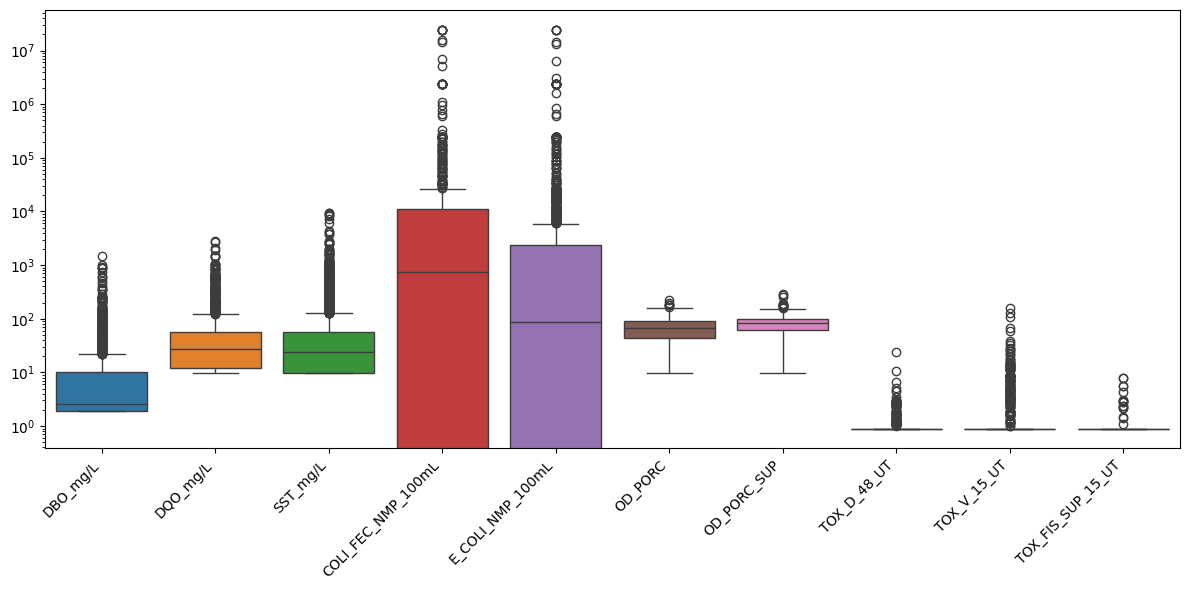

In [ ]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df[columnas_filtradas])
plt.xticks(rotation=45, ha='right')
plt.yscale('log') # Aplicar escala logarítmica al eje y para una mejor visualización, dada la amplia diferencia entre los rangos de las variables numéricas
plt.tight_layout()
plt.show()

### Observaciones:

*   Las mediciones de los parámetros fisicoquímicos DQO y SST presentan medianas y distribuciones de datos similares, mientras que las mediciones de DBO son considerablemente más bajas. En los tres parámetros se identifica una alta presencia de valores atípicos.
*   Las mediciones de los parámetros microbiológicos COLI y E_COLI presentan una amplia dispersión de datos, evidenciada por la amplitud de sus cajas en comparación con el resto de las variables. Además, presentan una gran cantidad de valores atípicos.
*   Las mediciones de Oxígeno Disuelto ("OD_") muestran un comportamiento similar entre sí, con mediana y dispersión similar, además de relativamente pocos valores outliers.
*   Las variables relacionadas con Toxicidad ("TOX_") presentan el 50% central de sus datos muy concentrado alrededor de la mediana, lo cual indica una baja dispersión. Sin embargo, se identifica una cantidad considerable de outliers.


## Matriz de Correlación

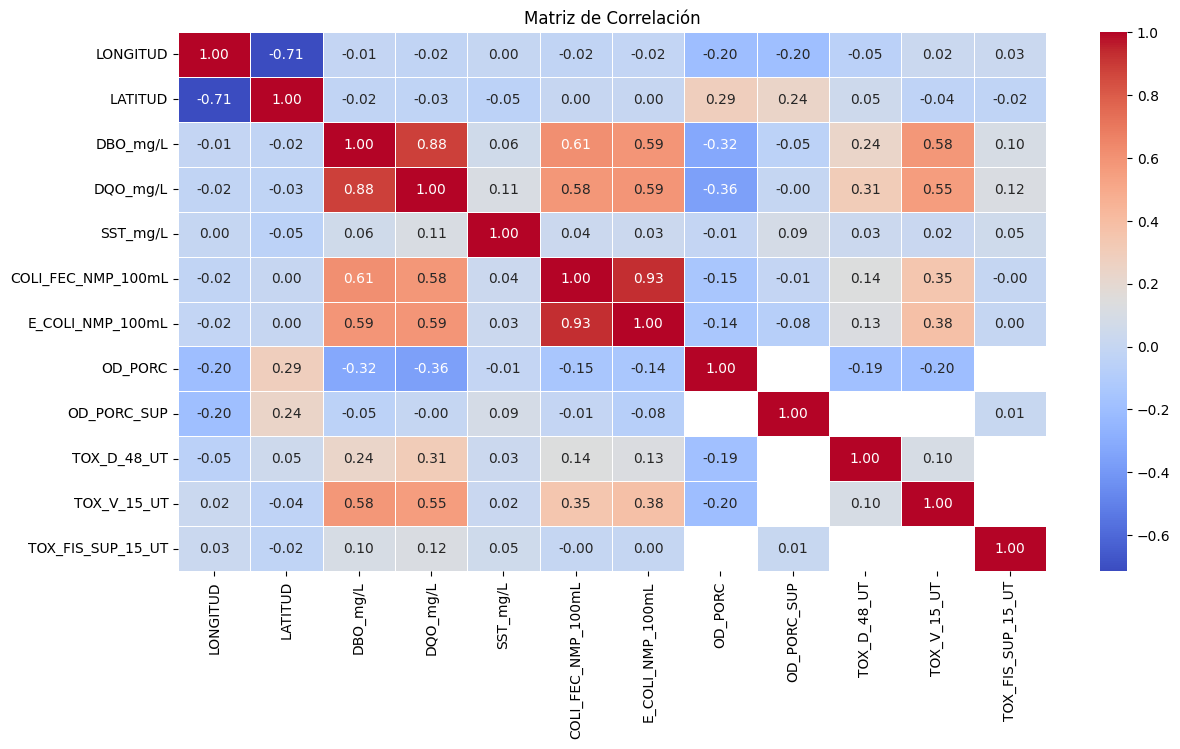

In [ ]:
# Filtrar solo las columnas numéricas, excluyendo 'PERIODO'
numerical_cols = df.select_dtypes(include='number').columns.tolist()
numerical_cols = [col for col in numerical_cols if col != 'PERIODO']

# Calcular la matriz de correlación
correlation_matrix = df[numerical_cols].corr()

# Crear un heatmap para visualizar la correlación
plt.figure(figsize=(14, 7))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", cbar=True, linewidths=0.5)
plt.title('Matriz de Correlación')
plt.show()


**Observaciones**

*   Se identifica una fuerte correlación positiva (0.93) entre los parámetros COLI_FEC y E_COLI, lo cual es completamente esperable ya que ambos son indicadores de la presencia de coliformes fecales.
*   Existe una fuerte correlación positiva (0.88) entre los parámetros DQO (Demanda Química de Oxígeno) y DBO (Demanda Bioquímica de Oxígeno). Esto tiene sentido ya que tanto DQO como DBO están influenciadas por la presencia de materia orgánica en el agua.
*   En general, las variables muestran correlaciones bajas, mientras que las correlaciones moderadas a altas se deben a que son variables que son variables que están directamente relacionadas entre sí en términos de la calidad del agua.  



# 3. Análisis con K-Means

In [ ]:
#Importación de Librerías
from sklearn.cluster import KMeans
from sklearn.preprocessing import LabelEncoder, StandardScaler
from matplotlib.colors import LinearSegmentedColormap
import folium
from sklearn.metrics import silhouette_score
import matplotlib.cm as cm
import matplotlib.colors as colors

Cambio de codificación de la variable 'SEMAFORO'

In [ ]:
df['SEMAFORO'].head(5) #Codificación original

,SEMAFORO
0,Rojo
1,Verde
2,Verde
3,Verde
4,Verde


In [ ]:
#LabelEncoder
encoder = LabelEncoder()
df['SEMAFORO_E'] = encoder.fit_transform(df['SEMAFORO'])
df['SEMAFORO_E'].head(5) #codificación numérica

,SEMAFORO_E
0,1
1,2
2,2
3,2
4,2


Selección de Variables Dependientes e Independientes

In [ ]:
X = df[['LATITUD', 'LONGITUD']] #Variables independientes

y_true = df['SEMAFORO'] # Variable a predecir si se utilizan modelos de clasificación

K-Means es un algoritmo de clustering no supervisado, por lo que no debería basarse en una variable dependiente ('SEMAFORO'). En este caso, se incluye la variable SEMAFORO ya que se quiere evaluar su relación con la ubicación geográfica del sitio de muestreo.

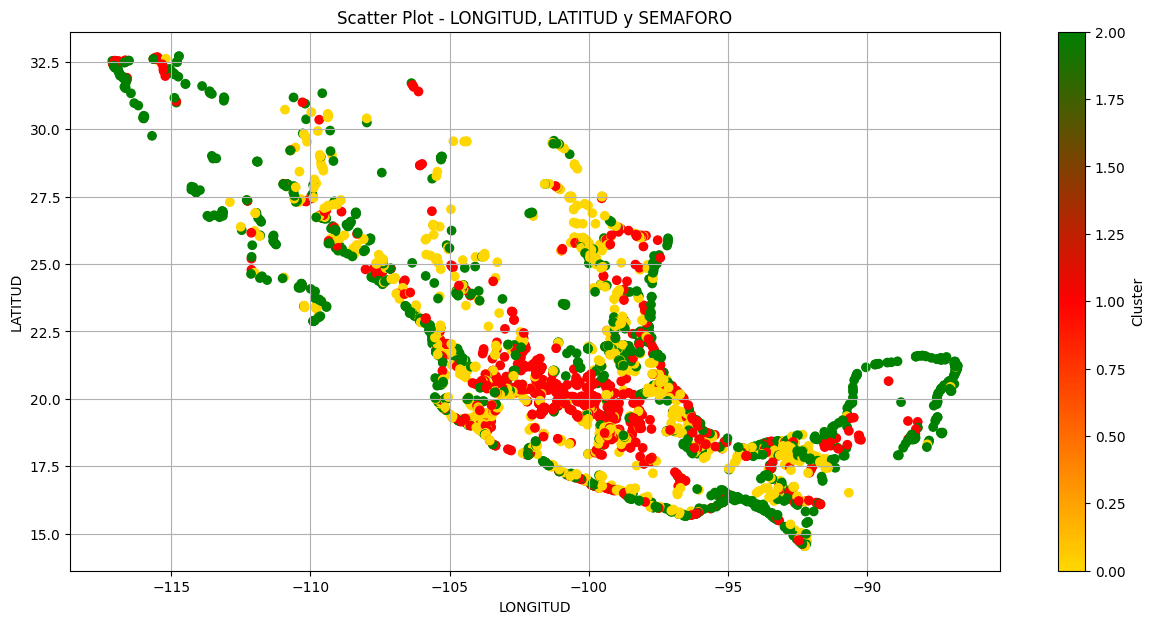

In [ ]:
colores = ["gold", "red", "green"]
cmap_gradual = LinearSegmentedColormap.from_list("semaforo_gradual", colores)

plt.figure(figsize=(15, 7))
plt.scatter(df['LONGITUD'], df['LATITUD'], c=df['SEMAFORO_E'], cmap=cmap_gradual)
plt.xlabel('LONGITUD')
plt.ylabel('LATITUD')
plt.title('Scatter Plot - LONGITUD, LATITUD y SEMAFORO')
plt.grid(True)
plt.colorbar(label='Cluster')
plt.show()

Al graficar la variable 'SEMAFORO' con respecto a 'LATITUD' y 'LONGITUD' se identifica que existe una ligera tendencia donde los muestreos realizados en el sector central de México evidencian mayor contaminación del agua. Esto es esperable ya que es trata de los sitios con mayor concentración poblacional.

### Preparación de Datos para K-Means

In [ ]:
# Seleccionar las columnas que se usarán para el K-Means
data = df[['LATITUD', 'LONGITUD', 'SEMAFORO_E']]
data.head(7)

,LATITUD,LONGITUD,SEMAFORO_E
0,22.25,-102.34,1
1,22.90,-109.84,2
2,22.90,-109.86,2
3,22.90,-109.89,2
4,22.88,-109.90,2
5,22.88,-109.90,2
6,22.88,-109.91,2


In [ ]:
# Escalar las variables
scaler = StandardScaler()
coords_scaled = scaler.fit_transform(df[['LATITUD', 'LONGITUD']])

# Concatenar las coordenadas escaladas con SEMAFORO_E
data_scaled = np.hstack((coords_scaled, df[['SEMAFORO_E']].values))

## Métodos de selección de *k*

Con la finalidad de seleccionar de forma objetiva el valor de k para la aplicación del algoritmo K-Means, se utilizan dos métodos: el método del codo y el método de la silueta

### Método del Codo

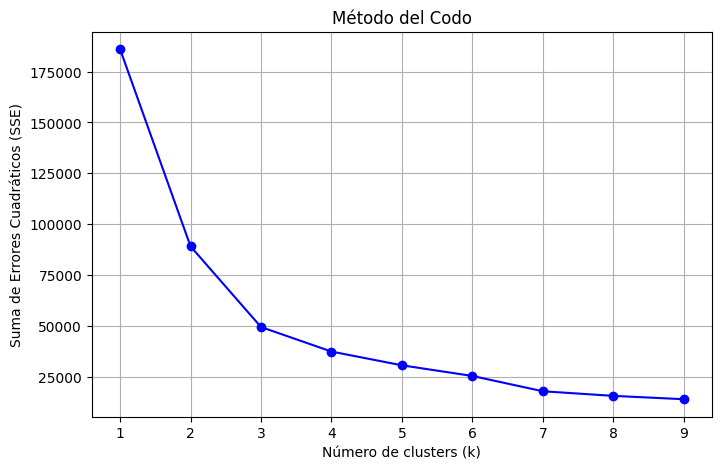

In [ ]:
# Método del Codo
inertia = []
K = range(1, 10)
for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(data)
    inertia.append(kmeans.inertia_)
plt.figure(figsize=(8, 5))
plt.plot(range(1, 10), inertia, "bo-")
plt.xlabel("Número de clusters (k)")
plt.ylabel("Suma de Errores Cuadráticos (SSE)")
plt.title("Método del Codo")
plt.grid(True)
plt.show()

Al aplicar el Método del Codo se busca obtener un "codo" en la curva donde la disminución de SSE se estabiliza, lo cual sugiere el k óptimo. En este caso, se evidencia un ligero codo en **k=3**, sin embargo, la curva es relativamente suave, por lo que no se identifica claramente un codo.

### Método del Silhouette

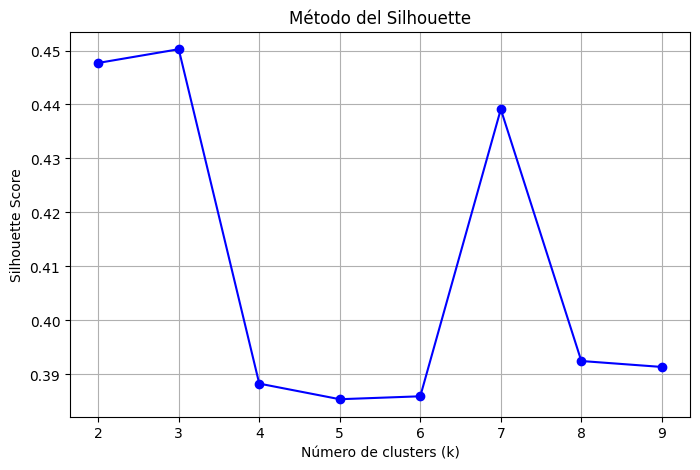

In [ ]:
from sklearn.metrics import silhouette_score

silhouette_scores = []
K = range(2, 10)  # El silhouette no es válido para k=1

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(data)
    score = silhouette_score(data, labels)
    silhouette_scores.append(score)

# Graficar los resultados
plt.figure(figsize=(8, 5))
plt.plot(K, silhouette_scores, "bo-")
plt.xlabel("Número de clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Método del Silhouette")
plt.grid(True)
plt.show()


El Método de la Silueta establece que mientras más cercano sea el coeficiente de Silhouette mejor es la asignación. En este caso, el valor más alto de k es **k=3**, con un coeficiente de Silhouette de aproximadamente 0.465.

## K-Means

In [ ]:
# Aplicar K-Means (k=3)
kmeans = KMeans(n_clusters=3, random_state=42, init='k-means++')
df['Cluster'] = kmeans.fit_predict(data_scaled)
df['Cluster'].head(7)

,Cluster
0,1
1,2
2,2
3,2
4,2
5,2
6,2


# 4. Visualización de Agrupamiento con K-Means

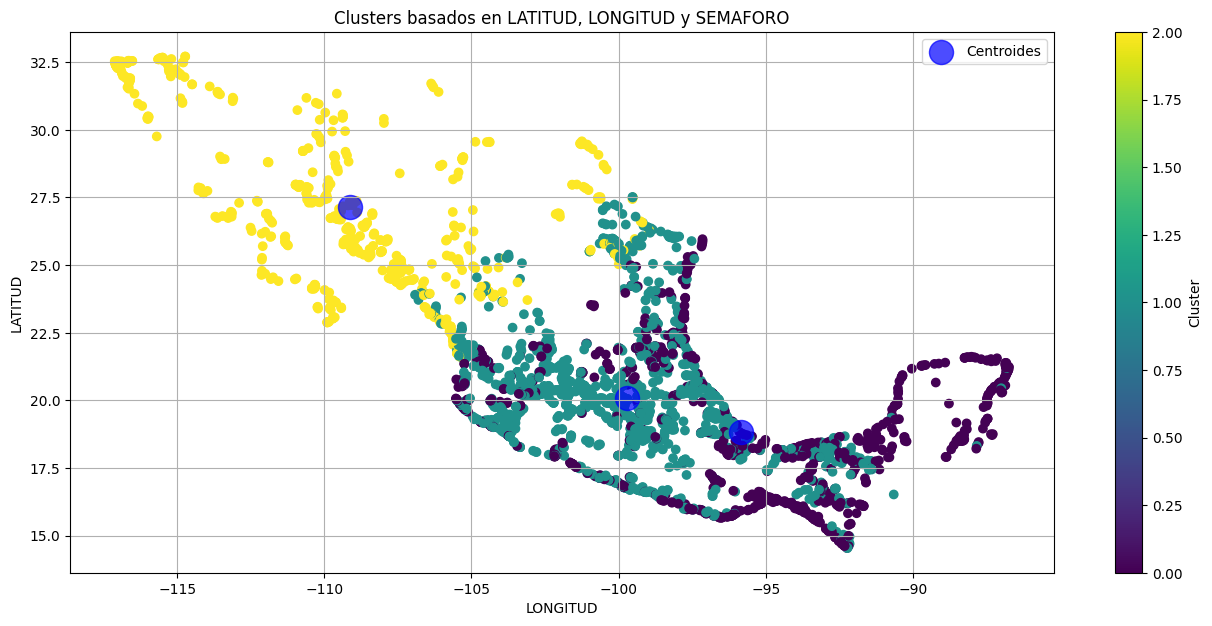

In [ ]:
plt.figure(figsize=(13, 6))
plt.scatter(df['LONGITUD'], df['LATITUD'], c=df['Cluster'], cmap='viridis')
plt.colorbar(label='Cluster')

# Para mostrar centroides
centers = kmeans.cluster_centers_
centers_coords = scaler.inverse_transform(centers[:, :2])

plt.scatter(centers_coords[:, 1], centers_coords[:, 0], c='blue', s=300, alpha=0.7, label='Centroides')

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.xlabel('LONGITUD')
plt.ylabel('LATITUD')
plt.title('Clusters basados en LATITUD, LONGITUD y SEMAFORO')
plt.show()

In [ ]:
# Crear el mapa de México
mapa = folium.Map(location=[23.6345, -102.5528], zoom_start=5,tiles='Esri WorldStreetMap')

# Crear una lista de colores para los clusters
norm = colors.Normalize(vmin=df['Cluster'].min(), vmax=df['Cluster'].max())
viridis = cm.get_cmap('viridis')

# Función para obtener color según cluster
def get_color(cluster):
    rgba = viridis(norm(cluster))
    return colors.to_hex(rgba)

# Agregar puntos al mapa
for _, row in df.iterrows():
    folium.CircleMarker(
        location=[row['LATITUD'], row['LONGITUD']],
        radius=5,
        color='white',
        fill=True,
        fill_color=get_color(row['Cluster']),
        fill_opacity=1,
        weight=1
    ).add_to(mapa)

# Desactivar el zoom con la rueda del mouse
mapa.options['scrollWheelZoom'] = False

# Mostrar el mapa
mapa

<ipython-input-608-622da5f79f76>:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  viridis = cm.get_cmap('viridis')


In [ ]:
# Ver la distribución de SEMAFORO en cada cluster
distribucion_semaforo = df.groupby('Cluster')['SEMAFORO'].value_counts()
distribucion_semaforo

Cluster  SEMAFORO
0        Verde       886
         Rojo        139
1        Amarillo    974
         Rojo        827
2        Verde       380
         Amarillo    161
         Rojo        121
Name: count, dtype: int64



---



# 5. Conclusiones

* A partir del análisis de clustering realizado a partir las variables de ubicación (LATITUD y LONGITUD) junto con el nivel de contaminación (SEMAFORO), se identificaron tres grupos distintos (Cluster 0, 1 y 2).
* En el Cluster 0 se observa que la mayoría de los puntos están asociados con un semáforo verde (886), lo que sugiere que las aguas superficiales en estas áreas presentan niveles más bajas de contaminación.
* En el Cluster 1, tanto el semáforo amarillo como rojo están distribuidos de manera equilibrada (974 y 827 respectivamente), lo que indica que en esta área predominan los niveles medios-altos de contaminación en el agua.
* El Cluster 2 presenta una mayoría de semáforos verdes (380) y amarillos (161), lo que sugiere que los niveles de contaminación en las aguas son intermedios.
* En conclusión, el análisis demuestra una relación moderada entre la calidad del agua superficial y la ubicación geográfica, lo que podría estar vinculado a factores ambientales, urbanos e industriales que influyen directamente en la contaminación de las aguas en diferentes regiones de la República Mexicana.



---

